# Chapter 07: Tests on von Mises Distributions

Source span: printed pages 119-144; PDF pages 136-160.

The textbook PDF was used only for source orientation: chapter order, terminology, and the inferential targets. The prose, code, diagrams, simulated data, and checks below are original teaching materials.

**Standalone chapter question.** Once a circular sample is plausibly modeled by a von Mises distribution, how do the resultant vectors tell us whether a mean direction or a concentration has changed?

The chapter's recurring geometry is simple and strict: every observation is a unit vector, every sample is summarized by its resultant vector, and every test asks whether a visible vector discrepancy is larger than von Mises sampling variation would explain.

## Translation Guide

| Book concept | Computational object used here | What to inspect |
| --- | --- | --- |
| Circular observation | Unit complex number `exp(1j*theta)` | Rotating all data changes phases but not resultant lengths. |
| Mean direction | Argument of the sample resultant | It is a direction on the circle, not a point on a line. |
| Resultant length | `L = abs(sum(exp(1j*theta)))`; mean resultant `rbar = L/n` | Long resultants indicate high concentration. |
| von Mises concentration | Bessel-ratio inverse solving `A1(kappa)=rbar` | The same mean direction is less persuasive when `rbar` is short. |
| One-sample mean test | Conditional arc for the sample mean direction given `L` | Rejection is an arc opposite the null direction. |
| Confidence interval for a mean direction | Arc centered at the observed mean direction | Width is angular and wraps through `-pi/pi` if needed. |
| Two-sample mean comparison | Triangle formed by two group resultants and their sum | `L1 + L2 - L` is the visible between-group gap. |
| Watson-Williams ANOVA | Decomposition `N - L = (sum L_i - L) + (N - sum L_i)` | The F statistic is between-resultant loss divided by within-resultant loss. |
| Equal concentration assumption | Bootstrap check on fitted group concentrations | Check this before trusting equal-concentration mean-direction ANOVA. |
| von-Misesness | Residual second harmonic after fitting the first harmonic | A strong second harmonic indicates shape not captured by one von Mises bump. |

In [1]:
from pathlib import Path
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special, stats
import sympy as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display


def find_book_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Directional Statistics.pdf").exists():
            return candidate
        nested = candidate / "Directional-Statistics"
        if (nested / "AGENTS.md").exists() and (nested / "Directional Statistics.pdf").exists():
            return nested
    raise RuntimeError("Could not locate Directional-Statistics book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.circular import A1, inverse_A1, von_mises_pdf, wrap_angle
from utils.validation import assert_artifacts

TOPIC = "chapter-07"
TAU = 2 * np.pi
RNG = np.random.default_rng(7107)

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.18, "font.size": 10})


def rad(degrees):
    return np.deg2rad(degrees)


def deg(radians):
    return np.rad2deg(wrap_angle(radians))


def angle_distance(a, b):
    return float(abs(wrap_angle(a - b)))


def estimate_kappa(rbar: float) -> float:
    rbar = float(np.clip(rbar, 1e-8, 0.999999))
    return float(inverse_A1(rbar))


def bessel_ratio(order: int, kappa: float) -> float:
    return float(special.iv(order, kappa) / max(special.iv(0, kappa), 1e-300))


def group_summary(theta) -> dict:
    theta = wrap_angle(np.asarray(theta, dtype=float))
    z = np.exp(1j * theta)
    vector = z.sum()
    n = int(theta.size)
    L = float(abs(vector))
    rbar = L / n
    return {"n": n, "C": float(vector.real), "S": float(vector.imag), "L": L, "rbar": float(rbar), "mean": float(np.angle(vector)), "kappa_hat": estimate_kappa(rbar)}


def central_vonmises_half_width(concentration: float, coverage: float = 0.95) -> float:
    concentration = float(max(concentration, 0.0))
    if concentration < 1e-10:
        return float(np.pi * coverage)
    dist = stats.vonmises(kappa=concentration, loc=0.0)
    return float(optimize.brentq(lambda h: float(dist.cdf(h) - dist.cdf(-h)) - coverage, 0.0, np.pi))


def conditional_mean_pvalue(mean_angle: float, null_mu: float, concentration: float) -> float:
    observed = angle_distance(mean_angle, null_mu)
    if concentration < 1e-10:
        return float(max(0.0, 1.0 - observed / np.pi))
    dist = stats.vonmises(kappa=concentration, loc=0.0)
    central = float(dist.cdf(observed) - dist.cdf(-observed))
    return float(np.clip(1.0 - central, 0.0, 1.0))


def mean_confidence_arc(summary: dict, alpha: float = 0.05, kappa: float | None = None) -> dict:
    kappa_used = float(summary["kappa_hat"] if kappa is None else kappa)
    conditional_concentration = max(kappa_used * summary["L"], 0.0)
    half_width = central_vonmises_half_width(conditional_concentration, 1 - alpha)
    return {"center": summary["mean"], "half_width": half_width, "lower": float(wrap_angle(summary["mean"] - half_width)), "upper": float(wrap_angle(summary["mean"] + half_width)), "conditional_concentration": conditional_concentration, "kappa_used": kappa_used}


def resultant_decomposition(groups) -> dict:
    summaries = [group_summary(g) for g in groups]
    total = group_summary(np.concatenate(groups))
    N = sum(s["n"] for s in summaries)
    q = len(summaries)
    sum_L = float(sum(s["L"] for s in summaries))
    between = float(sum_L - total["L"])
    within = float(N - sum_L)
    total_loss = float(N - total["L"])
    f_ww = float(((N - q) * between) / ((q - 1) * within)) if within > 0 and q > 1 else np.nan
    p_ww = float(stats.f.sf(f_ww, q - 1, N - q)) if np.isfinite(f_ww) else np.nan
    kappa_pooled = estimate_kappa(sum_L / N)
    correction = 1.0 + 3.0 / (8.0 * kappa_pooled) if kappa_pooled > 1e-10 else np.inf
    f_corrected = float(correction * f_ww) if np.isfinite(f_ww) else np.nan
    p_corrected = float(stats.f.sf(f_corrected, q - 1, N - q)) if np.isfinite(f_corrected) else np.nan
    return {"summaries": summaries, "total": total, "N": N, "q": q, "sum_L": sum_L, "between": between, "within": within, "total_loss": total_loss, "identity_residual": float(total_loss - between - within), "F_WW": f_ww, "p_WW": p_ww, "kappa_pooled_within": kappa_pooled, "correction_factor": correction, "F_WW_corrected": f_corrected, "p_WW_corrected": p_corrected}


def second_harmonic_diagnostic(theta) -> dict:
    theta = wrap_angle(np.asarray(theta, dtype=float))
    summary = group_summary(theta)
    x = wrap_angle(theta - summary["mean"])
    k = summary["kappa_hat"]
    a2 = bessel_ratio(2, k)
    a4 = bessel_ratio(4, k)
    c2 = float(np.mean(np.cos(2 * x)))
    s2 = float(np.mean(np.sin(2 * x)))
    var_c2 = max((1 + a4) / 2 - a2**2, 1e-9)
    var_s2 = max((1 - a4) / 2, 1e-9)
    stat = len(theta) * ((c2 - a2) ** 2 / var_c2 + s2**2 / var_s2)
    return {"n": int(len(theta)), "mean_deg": float(deg(summary["mean"])), "rbar": summary["rbar"], "kappa_hat": k, "cos2_observed": c2, "cos2_von_mises_fit": a2, "sin2_observed": s2, "statistic": float(stat), "p_chi2_df2": float(stats.chi2.sf(stat, 2))}


def concentration_homogeneity_stat(groups) -> tuple[float, list[dict]]:
    summaries = [group_summary(g) for g in groups]
    log_kappa = np.log(np.maximum([s["kappa_hat"] for s in summaries], 1e-6))
    weights = np.asarray([max(s["n"] - 1, 1) for s in summaries], dtype=float)
    center = float(np.average(log_kappa, weights=weights))
    return float(np.sum(weights * (log_kappa - center) ** 2)), summaries


def concentration_homogeneity_bootstrap(groups, B: int = 300, seed: int = 0) -> dict:
    groups = [wrap_angle(np.asarray(g, dtype=float)) for g in groups]
    obs, summaries = concentration_homogeneity_stat(groups)
    N = sum(s["n"] for s in summaries)
    pooled_kappa = estimate_kappa(sum(s["L"] for s in summaries) / N)
    rng = np.random.default_rng(seed)
    null_stats = []
    for _ in range(B):
        simulated = [rng.vonmises(s["mean"], pooled_kappa, s["n"]) for s in summaries]
        null_stats.append(concentration_homogeneity_stat(simulated)[0])
    null_stats = np.asarray(null_stats)
    p_value = float((1 + np.sum(null_stats >= obs)) / (B + 1))
    return {"observed": obs, "p_value": p_value, "null_stats": null_stats, "pooled_kappa": pooled_kappa, "kappa_hats": [s["kappa_hat"] for s in summaries], "rbar": [s["rbar"] for s in summaries], "n": [s["n"] for s in summaries]}

print(f"BOOK_ROOT = {BOOK_ROOT}")

BOOK_ROOT = D:\Geometry\Directional-Statistics


## Chapter Route and Library Choices

The notebook follows the chapter in six computational moves.

1. Build one-sample mean-direction tests as arcs from the conditional von Mises law of the sample mean direction.
2. Turn confidence intervals into visible arcs, then verify their coverage by simulation.
3. Draw the two-sample resultant triangle and check its cosine-rule identity symbolically and numerically.
4. Decompose multi-sample circular ANOVA into between-resultant and within-resultant losses.
5. Test the equal-concentration assumption before interpreting Watson-Williams mean-direction tests.
6. Diagnose von-Misesness by looking for second-harmonic structure left after the fitted first harmonic.

Library routing: Matplotlib is used for durable circular and vector diagrams; Plotly is used for the parameterized Watson-Williams explorer; SciPy supplies von Mises CDFs, Bessel functions, and F/chi-square reference laws; SymPy checks the resultant identity exactly; pandas stores the applied lab table.

## One-Sample Mean-Direction Tests as Arcs

For a sample `theta_1, ..., theta_n`, write the resultant as

`sum exp(i theta_j) = L exp(i theta_hat)`.

Under a von Mises model with mean direction `mu`, the conditional distribution of `theta_hat` given `L` is again a von Mises law, centered at `mu`, with concentration proportional to `kappa * L`. That turns a mean-direction test into an arc question: is the observed mean direction too far around the circle from the null direction?

The figure below shows both sides of the same test. The polar panel shows the sample, the observed mean direction, the null direction, and the confidence arc. The density panel unwraps the conditional law around the null mean so the rejection tail is visible without pretending the circle is a line.

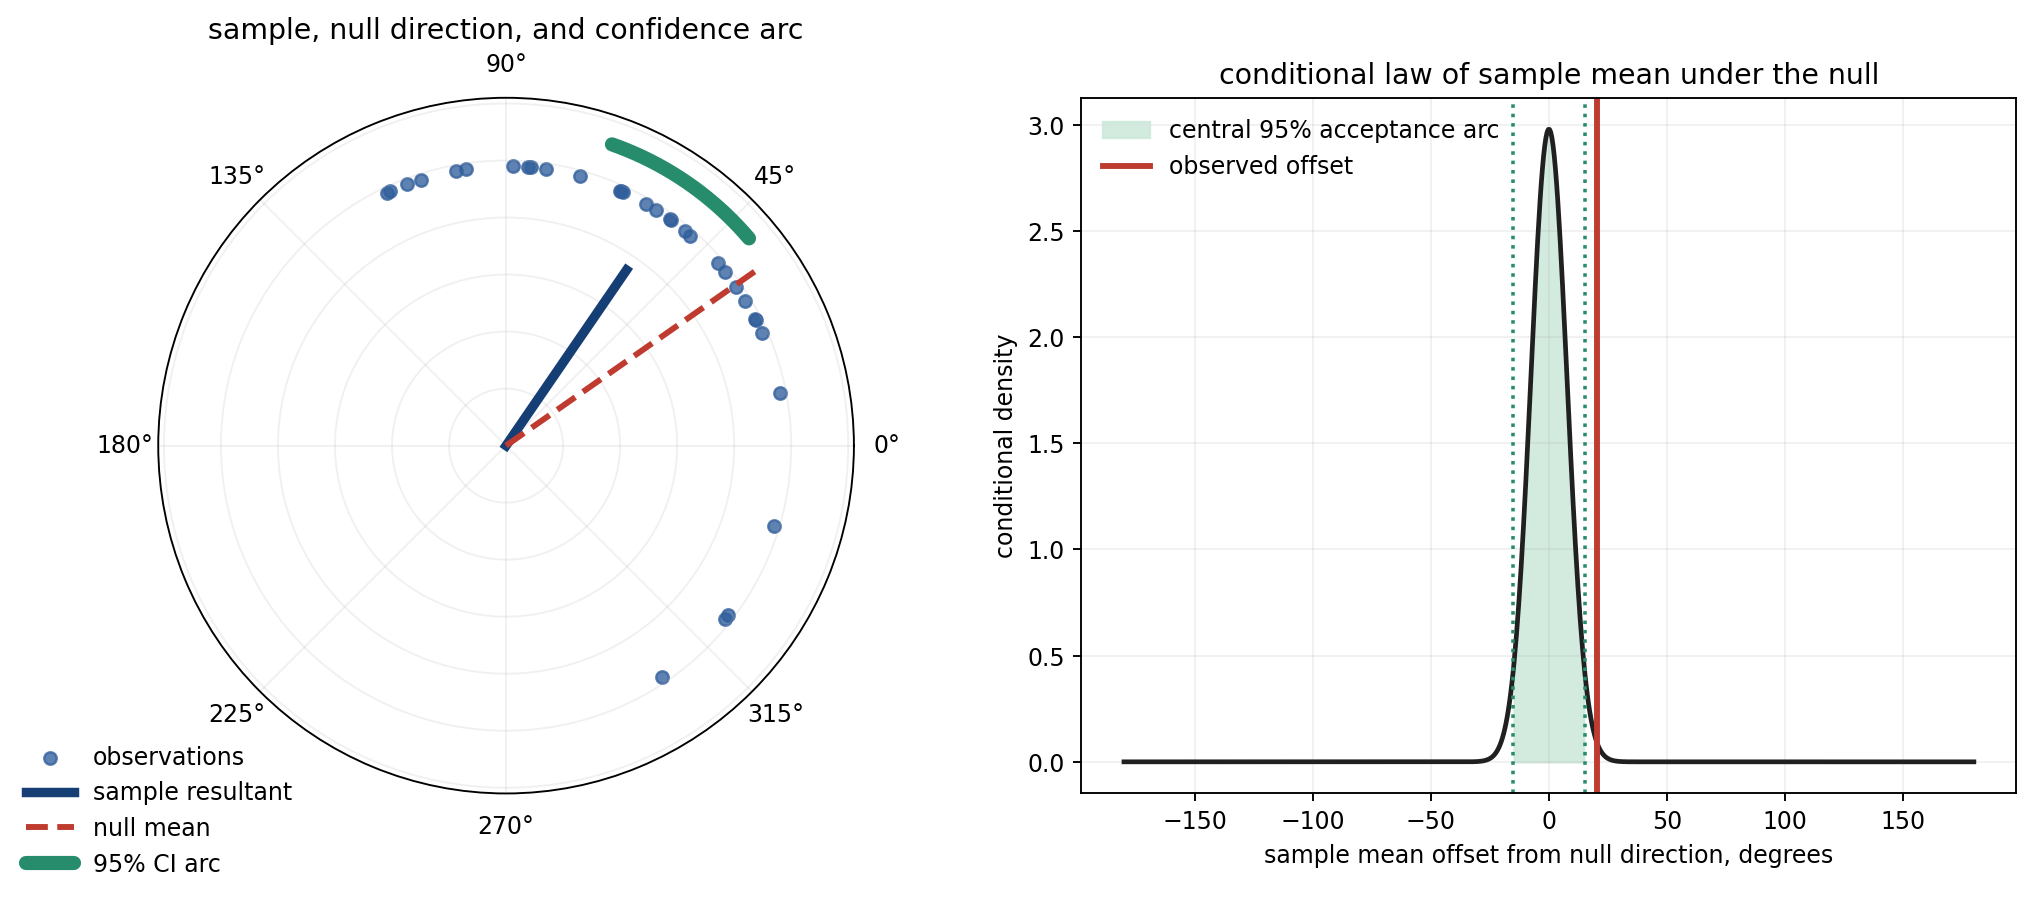

,quantity,value
0,n,32.000000
1,"mean direction, degrees",55.553461
2,mean resultant rbar,0.746897
3,kappa_hat,2.343915
4,"95% half-width, degrees",15.080875
5,"null direction, degrees",35.000000
6,conditional p-value,0.007708
7,LR-style chi-square p-value,0.007572
8,score-style normal p-value,0.008595


In [2]:
theta_one = RNG.vonmises(rad(68), 2.4, 32)
one_summary = group_summary(theta_one)
null_mu = rad(35)
arc_est = mean_confidence_arc(one_summary, alpha=0.05)
arc_known = mean_confidence_arc(one_summary, alpha=0.05, kappa=2.4)
cond_conc = arc_est["conditional_concentration"]
conditional_p = conditional_mean_pvalue(one_summary["mean"], null_mu, cond_conc)
lr_stat = 2 * one_summary["kappa_hat"] * one_summary["L"] * (1 - np.cos(wrap_angle(one_summary["mean"] - null_mu)))
lr_p = float(stats.chi2.sf(lr_stat, 1))
z_score = math.sqrt(max(one_summary["kappa_hat"] * one_summary["L"], 1e-12)) * math.sin(wrap_angle(one_summary["mean"] - null_mu))
z_p = float(2 * stats.norm.sf(abs(z_score)))

fig = plt.figure(figsize=(12, 5.2), constrained_layout=True)
ax = fig.add_subplot(1, 2, 1, projection="polar")
ax.set_title("sample, null direction, and confidence arc")
ax.set_ylim(0, 1.22)
ax.set_yticklabels([])
ax.scatter(theta_one, np.full_like(theta_one, 0.98), s=28, color="#315f9c", alpha=0.78, label="observations")
ax.plot([one_summary["mean"], one_summary["mean"]], [0, one_summary["rbar"]], color="#153e75", lw=4, label="sample resultant")
ax.plot([null_mu, null_mu], [0, 1.08], color="#bf3b2f", lw=2.5, linestyle="--", label="null mean")
arc_angles = one_summary["mean"] + np.linspace(-arc_est["half_width"], arc_est["half_width"], 240)
ax.plot(arc_angles, np.full_like(arc_angles, 1.12), color="#268c6c", lw=6, solid_capstyle="round", label="95% CI arc")
ax.legend(loc="lower left", bbox_to_anchor=(-0.22, -0.15), frameon=False)

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("conditional law of sample mean under the null")
delta_grid = np.linspace(-np.pi, np.pi, 720)
conditional_density = stats.vonmises(kappa=cond_conc).pdf(delta_grid)
observed_delta = wrap_angle(one_summary["mean"] - null_mu)
accept_half = central_vonmises_half_width(cond_conc, 0.95)
ax2.plot(np.rad2deg(delta_grid), conditional_density, color="#202020", lw=2)
ax2.fill_between(np.rad2deg(delta_grid), 0, conditional_density, where=np.abs(delta_grid) <= accept_half, color="#cfe8dc", alpha=0.9, label="central 95% acceptance arc")
ax2.axvline(np.rad2deg(observed_delta), color="#bf3b2f", lw=2.5, label="observed offset")
ax2.axvline(-np.rad2deg(accept_half), color="#268c6c", lw=1.5, linestyle=":")
ax2.axvline(np.rad2deg(accept_half), color="#268c6c", lw=1.5, linestyle=":")
ax2.set_xlabel("sample mean offset from null direction, degrees")
ax2.set_ylabel("conditional density")
ax2.legend(frameon=False)

mean_arc_path = save_matplotlib(fig, TOPIC, "figures", "mean-direction-confidence-arc.png", dpi=170)
plt.close(fig)
display_artifact(mean_arc_path, width=920)

one_sample_table = pd.DataFrame([
    {"quantity": "n", "value": one_summary["n"]},
    {"quantity": "mean direction, degrees", "value": deg(one_summary["mean"])},
    {"quantity": "mean resultant rbar", "value": one_summary["rbar"]},
    {"quantity": "kappa_hat", "value": one_summary["kappa_hat"]},
    {"quantity": "95% half-width, degrees", "value": np.rad2deg(arc_est["half_width"])},
    {"quantity": "null direction, degrees", "value": deg(null_mu)},
    {"quantity": "conditional p-value", "value": conditional_p},
    {"quantity": "LR-style chi-square p-value", "value": lr_p},
    {"quantity": "score-style normal p-value", "value": z_p},
])
display(one_sample_table)

### Coverage Sanity Check

The conditional-arc construction has a useful built-in validation. If `kappa` is known, then conditioning on the observed resultant length makes the mean direction exactly a von Mises draw with concentration `kappa * L`. The next cell simulates that claim directly: each replicate builds a 95% conditional arc and records whether the true mean direction lies inside it.

In [3]:
coverage_rng = np.random.default_rng(710701)
coverage_hits = []
coverage_widths = []
for _ in range(1000):
    sample = coverage_rng.vonmises(rad(68), 2.4, 32)
    s = group_summary(sample)
    arc = mean_confidence_arc(s, alpha=0.05, kappa=2.4)
    coverage_hits.append(angle_distance(s["mean"], rad(68)) <= arc["half_width"])
    coverage_widths.append(np.rad2deg(arc["half_width"]))
coverage_rate = float(np.mean(coverage_hits))
coverage_summary = {"replicates": len(coverage_hits), "target": 0.95, "coverage_rate": coverage_rate, "mean_half_width_degrees": float(np.mean(coverage_widths)), "sd_half_width_degrees": float(np.std(coverage_widths))}
assert 0.92 <= coverage_rate <= 0.98, coverage_summary
coverage_summary

{'replicates': 1000,
 'target': 0.95,
 'coverage_rate': 0.949,
 'mean_half_width_degrees': 14.807339585545497,
 'sd_half_width_degrees': 0.6265524335924233}

## Two-Sample Resultant Geometry

Two independent von Mises samples with a common concentration can be compared through their group resultants. Let the group vectors have lengths `L1` and `L2`; the combined vector has length `L`. If the two mean directions agree, the vectors point nearly the same way and `L1 + L2 - L` is small. If they point apart, the triangle opens and that difference grows.

The Watson-Williams idea is to turn this geometric gap into an F statistic by comparing it with the within-group loss `N - L1 - L2`.

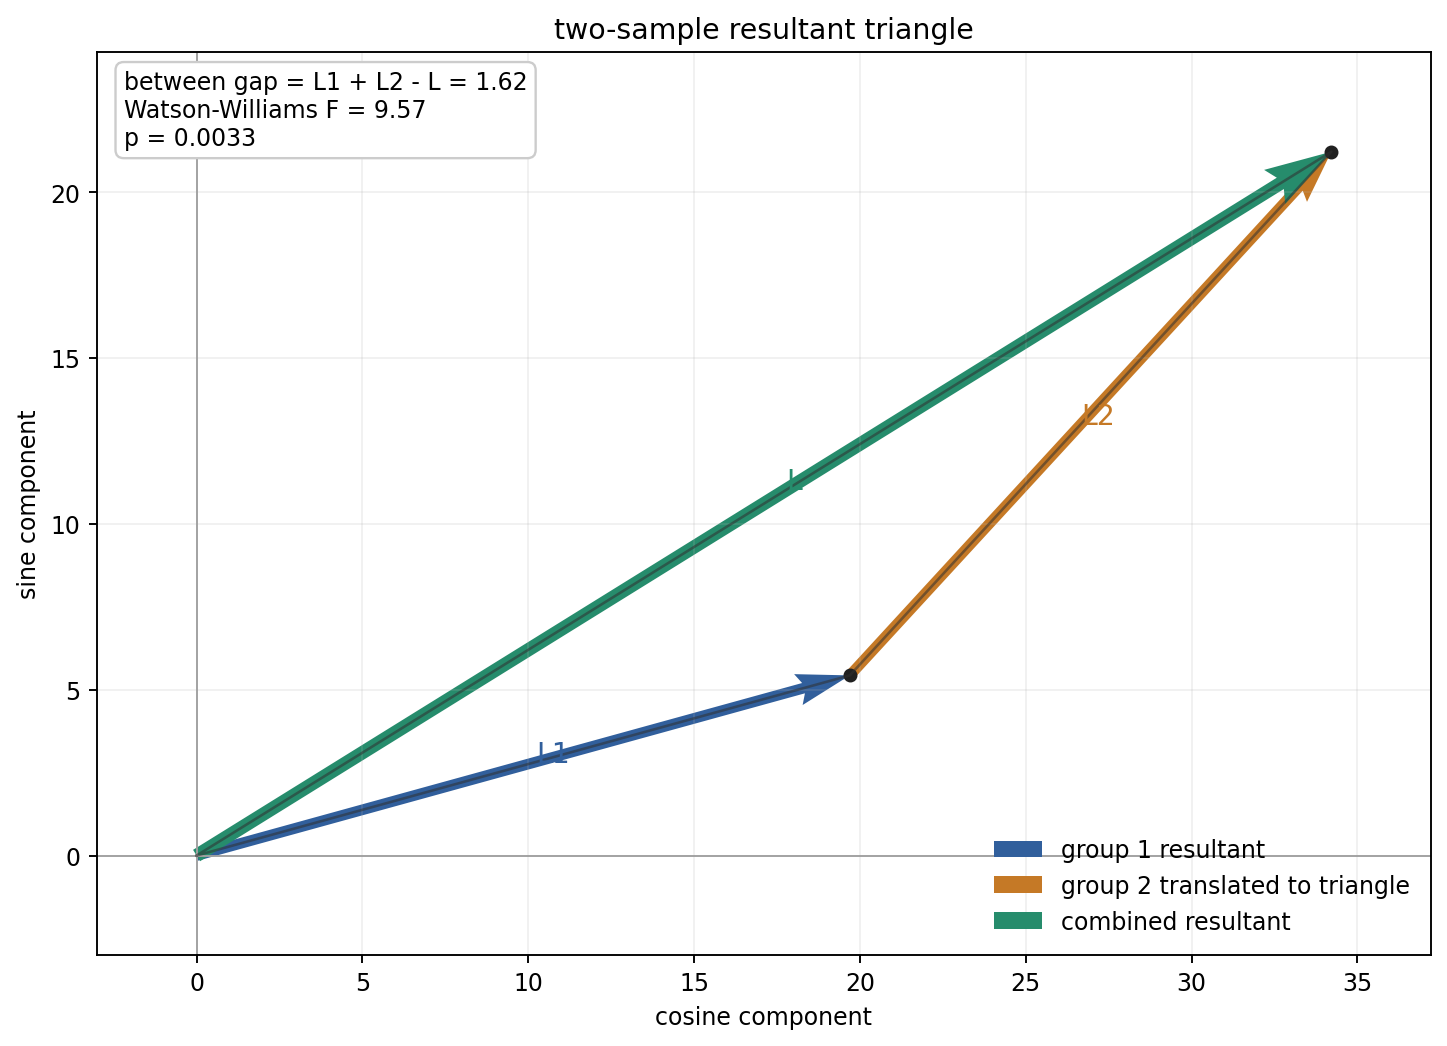

,sample,n,mean_deg,L,rbar,kappa_hat
0,group 1,26,15.416841,20.430096,0.785773,2.707192
1,group 2,24,47.400246,21.449076,0.893712,5.014205
2,combined,50,31.808067,40.259494,0.805190,2.936642


In [4]:
theta_a = RNG.vonmises(rad(18), 3.2, 26)
theta_b = RNG.vonmises(rad(58), 3.2, 24)
two_groups = [theta_a, theta_b]
two_dec = resultant_decomposition(two_groups)
s1, s2 = two_dec["summaries"]
combined = two_dec["total"]
x1, y1 = s1["C"], s1["S"]
x2, y2 = s2["C"], s2["S"]
xc, yc = combined["C"], combined["S"]

L1_sym, L2_sym, delta_sym = sp.symbols("L1 L2 delta", positive=True, real=True)
identity = sp.expand((L1_sym + L2_sym * sp.cos(delta_sym))**2 + (L2_sym * sp.sin(delta_sym))**2 - (L1_sym**2 + L2_sym**2 + 2 * L1_sym * L2_sym * sp.cos(delta_sym)))
assert sp.simplify(identity) == 0
numeric_cosine_residual = combined["L"]**2 - (s1["L"]**2 + s2["L"]**2 + 2 * s1["L"] * s2["L"] * np.cos(wrap_angle(s2["mean"] - s1["mean"])))
assert abs(numeric_cosine_residual) < 1e-10

fig, ax = plt.subplots(figsize=(8.4, 7.2), constrained_layout=True)
ax.set_title("two-sample resultant triangle")
ax.axhline(0, color="#a0a0a0", lw=0.8)
ax.axvline(0, color="#a0a0a0", lw=0.8)
ax.quiver(0, 0, x1, y1, angles="xy", scale_units="xy", scale=1, color="#315f9c", width=0.008, label="group 1 resultant")
ax.quiver(x1, y1, x2, y2, angles="xy", scale_units="xy", scale=1, color="#c57926", width=0.008, label="group 2 translated to triangle")
ax.quiver(0, 0, xc, yc, angles="xy", scale_units="xy", scale=1, color="#268c6c", width=0.010, label="combined resultant")
ax.plot([0, x1, xc, 0], [0, y1, yc, 0], color="#303030", lw=1.1, alpha=0.55)
ax.scatter([x1, xc], [y1, yc], color="#202020", s=24)
ax.text(x1 * 0.52, y1 * 0.52, "L1", color="#315f9c", fontsize=12)
ax.text(x1 + x2 * 0.48, y1 + y2 * 0.48, "L2", color="#c57926", fontsize=12)
ax.text(xc * 0.52, yc * 0.52, "L", color="#268c6c", fontsize=12)
ax.text(0.02, 0.98, f"between gap = L1 + L2 - L = {two_dec['between']:.2f}\nWatson-Williams F = {two_dec['F_WW']:.2f}\np = {two_dec['p_WW']:.4f}", transform=ax.transAxes, va="top", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc"})
margin = 3
xs = [0, x1, x1 + x2, xc]
ys = [0, y1, y1 + y2, yc]
ax.set_xlim(min(xs) - margin, max(xs) + margin)
ax.set_ylim(min(ys) - margin, max(ys) + margin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("cosine component")
ax.set_ylabel("sine component")
ax.legend(frameon=False, loc="lower right")

two_sample_path = save_matplotlib(fig, TOPIC, "figures", "two-sample-resultant-geometry.png", dpi=170)
plt.close(fig)
display_artifact(two_sample_path, width=760)

two_sample_table = pd.DataFrame([
    {"sample": "group 1", "n": s1["n"], "mean_deg": deg(s1["mean"]), "L": s1["L"], "rbar": s1["rbar"], "kappa_hat": s1["kappa_hat"]},
    {"sample": "group 2", "n": s2["n"], "mean_deg": deg(s2["mean"]), "L": s2["L"], "rbar": s2["rbar"], "kappa_hat": s2["kappa_hat"]},
    {"sample": "combined", "n": combined["n"], "mean_deg": deg(combined["mean"]), "L": combined["L"], "rbar": combined["rbar"], "kappa_hat": combined["kappa_hat"]},
])
display(two_sample_table)

## Watson-Williams Multi-Sample Decomposition

For `q` samples, the same geometry scales up. The combined loss from perfect alignment is

`N - L`.

The group-level decomposition is

`N - L = (sum L_i - L) + (N - sum L_i)`.

The first term is the between-sample loss: how much resultant length disappears when group vectors are forced into a single combined vector. The second term is the within-sample loss: how much length each group has already lost because its observations are dispersed around its own mean direction.

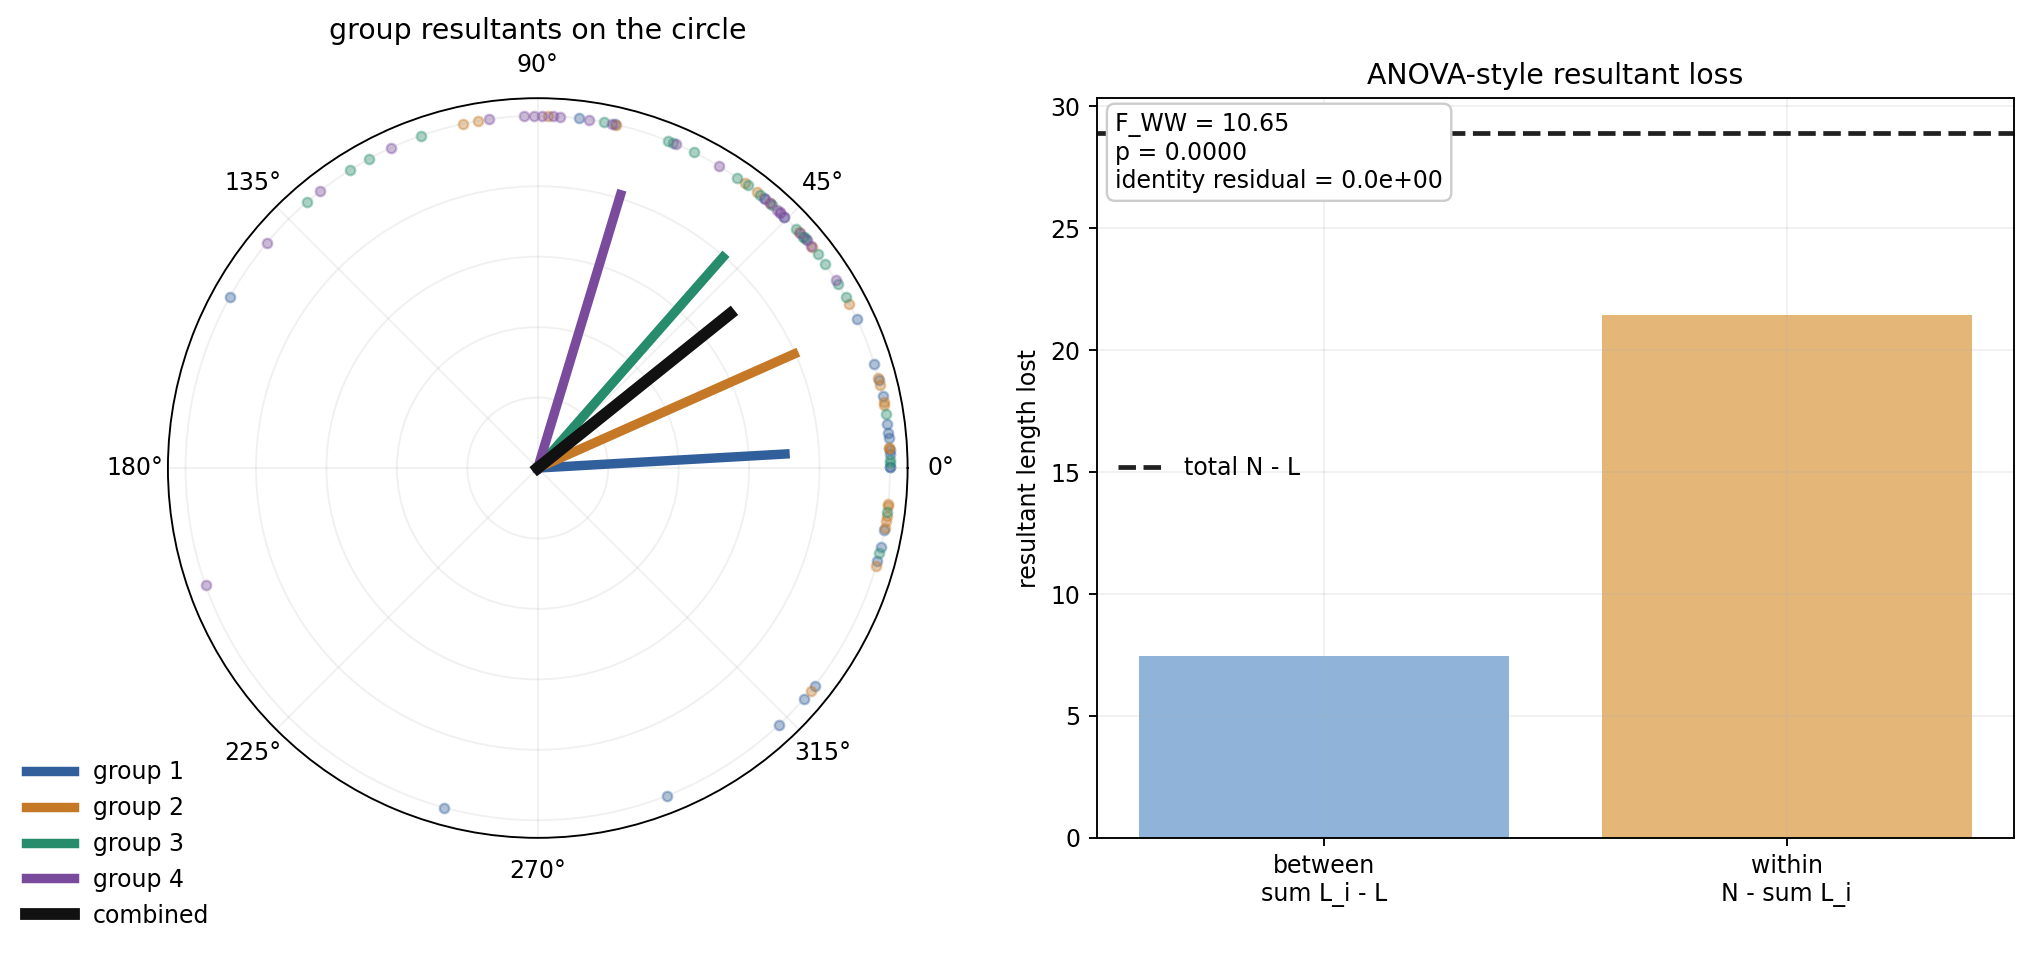

,group,n,mean_deg,L,rbar,kappa_hat
0,1,24,3.240781,16.873253,0.703052,2.032575
1,2,23,23.980242,18.315412,0.796322,2.826851
2,3,25,48.703100,19.907565,0.796303,2.826618
3,4,24,73.153900,19.458081,0.810753,3.010429


In [5]:
multi_means = rad(np.array([8, 22, 54, 72]))
multi_sizes = [24, 23, 25, 24]
multi_groups = [RNG.vonmises(mu, 3.4, n) for mu, n in zip(multi_means, multi_sizes)]
multi_dec = resultant_decomposition(multi_groups)
assert abs(multi_dec["identity_residual"]) < 1e-10

fig = plt.figure(figsize=(12, 5.5), constrained_layout=True)
ax = fig.add_subplot(1, 2, 1, projection="polar")
ax.set_title("group resultants on the circle")
ax.set_ylim(0, 1.05)
ax.set_yticklabels([])
colors = ["#315f9c", "#c57926", "#268c6c", "#7a4b9d"]
for i, (summary, color) in enumerate(zip(multi_dec["summaries"], colors), start=1):
    ax.plot([summary["mean"], summary["mean"]], [0, summary["rbar"]], lw=4, color=color, label=f"group {i}")
    ax.scatter(multi_groups[i - 1], np.full(summary["n"], 1.0), s=16, color=color, alpha=0.38)
ax.plot([multi_dec["total"]["mean"], multi_dec["total"]["mean"]], [0, multi_dec["total"]["rbar"]], lw=5, color="#111111", label="combined")
ax.legend(loc="lower left", bbox_to_anchor=(-0.22, -0.15), frameon=False)

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("ANOVA-style resultant loss")
parts = [multi_dec["between"], multi_dec["within"]]
ax2.bar(["between\nsum L_i - L", "within\nN - sum L_i"], parts, color=["#8fb3d9", "#e4b778"])
ax2.axhline(multi_dec["total_loss"], color="#202020", linestyle="--", lw=2, label="total N - L")
ax2.set_ylabel("resultant length lost")
ax2.text(0.02, 0.98, f"F_WW = {multi_dec['F_WW']:.2f}\np = {multi_dec['p_WW']:.4f}\nidentity residual = {multi_dec['identity_residual']:.1e}", transform=ax2.transAxes, va="top", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc"})
ax2.legend(frameon=False)

ww_decomp_path = save_matplotlib(fig, TOPIC, "figures", "watson-williams-decomposition.png", dpi=170)
plt.close(fig)
display_artifact(ww_decomp_path, width=920)

multi_table = pd.DataFrame([
    {"group": i + 1, "n": s["n"], "mean_deg": deg(s["mean"]), "L": s["L"], "rbar": s["rbar"], "kappa_hat": s["kappa_hat"]}
    for i, s in enumerate(multi_dec["summaries"])
])
display(multi_table)

### Interactive Resultant Explorer

The Plotly artifact below keeps group sizes and within-group concentration fixed while increasing separation among four group mean directions. Watch the combined resultant shrink and the between-loss bar grow. This is the geometry behind the Watson-Williams numerator.

In [6]:
def model_decomposition_for_separation(separation_deg: float, q: int = 4, n_each: int = 20, kappa: float = 3.2) -> dict:
    offsets = np.linspace(-0.5, 0.5, q) * rad(separation_deg)
    r = float(A1(kappa))
    summaries = []
    vectors = []
    for offset in offsets:
        L = n_each * r
        vectors.append(L * np.exp(1j * offset))
        summaries.append({"n": n_each, "L": L, "rbar": r, "mean": float(offset), "kappa_hat": kappa})
    total_vector = sum(vectors)
    N = q * n_each
    sum_L = sum(s["L"] for s in summaries)
    total_L = abs(total_vector)
    between = sum_L - total_L
    within = N - sum_L
    F = ((N - q) * between) / ((q - 1) * within) if within > 0 else np.nan
    return {"summaries": summaries, "total_mean": float(np.angle(total_vector)), "total_L": float(total_L), "between": float(between), "within": float(within), "F": float(F), "p": float(stats.f.sf(F, q - 1, N - q)) if np.isfinite(F) else np.nan}

separations = list(range(0, 91, 10))
model_states = [model_decomposition_for_separation(s) for s in separations]
base = model_states[0]
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "polar"}, {"type": "xy"}]], subplot_titles=("resultant directions", "loss decomposition"))
for i, summary in enumerate(base["summaries"], start=1):
    fig.add_trace(go.Scatterpolar(r=[0, summary["L"]], theta=[math.degrees(summary["mean"]), math.degrees(summary["mean"])], mode="lines+markers", name=f"group {i}", line={"width": 4}), row=1, col=1)
fig.add_trace(go.Scatterpolar(r=[0, base["total_L"]], theta=[math.degrees(base["total_mean"]), math.degrees(base["total_mean"])], mode="lines+markers", name="combined", line={"width": 6, "color": "black"}), row=1, col=1)
fig.add_trace(go.Bar(x=["between", "within"], y=[base["between"], base["within"]], marker_color=["#8fb3d9", "#e4b778"], name="loss"), row=1, col=2)

frames = []
for sep, state in zip(separations, model_states):
    frame_data = []
    for summary in state["summaries"]:
        frame_data.append(go.Scatterpolar(r=[0, summary["L"]], theta=[math.degrees(summary["mean"]), math.degrees(summary["mean"])]))
    frame_data.append(go.Scatterpolar(r=[0, state["total_L"]], theta=[math.degrees(state["total_mean"]), math.degrees(state["total_mean"])]))
    frame_data.append(go.Bar(x=["between", "within"], y=[state["between"], state["within"]]))
    frames.append(go.Frame(name=str(sep), data=frame_data, traces=list(range(6))))
fig.frames = frames
steps = [{"method": "animate", "label": str(sep), "args": [[str(sep)], {"mode": "immediate", "frame": {"duration": 250, "redraw": True}, "transition": {"duration": 0}}]} for sep in separations]
fig.update_layout(
    height=560,
    title="Watson-Williams geometry as group means separate",
    polar={"radialaxis": {"range": [0, 22], "showticklabels": True}},
    yaxis={"range": [0, max(max(s["between"], s["within"]) for s in model_states) * 1.15], "title": "resultant length lost"},
    sliders=[{"active": 0, "currentvalue": {"prefix": "separation span: ", "suffix": " degrees"}, "steps": steps}],
    updatemenus=[{"type": "buttons", "showactive": False, "x": 0.05, "y": -0.12, "buttons": [{"label": "play", "method": "animate", "args": [None, {"frame": {"duration": 350, "redraw": True}, "fromcurrent": True}]}, {"label": "pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}]}],
)
ww_explorer_path = save_plotly_html(fig, TOPIC, "interactive", "watson-williams-resultant-explorer.html", include_plotlyjs="cdn")
display_artifact(ww_explorer_path, width="100%", height=590)

## Concentration Homogeneity Before Circular ANOVA

The Watson-Williams mean-direction tests assume a common concentration. The chapter treats this as a separate inference problem, not a minor technicality. Here we use a parametric bootstrap screen: fit a common concentration from the within-group resultants, simulate groups with the fitted group mean directions and that common concentration, and compare the observed spread in fitted group concentrations with the bootstrap null spread.

This is not a replacement for every table-based approximation in the book. It is a visual, executable diagnostic that teaches the same dependency: a mean-direction ANOVA is hard to trust if the group concentrations are visibly inconsistent.

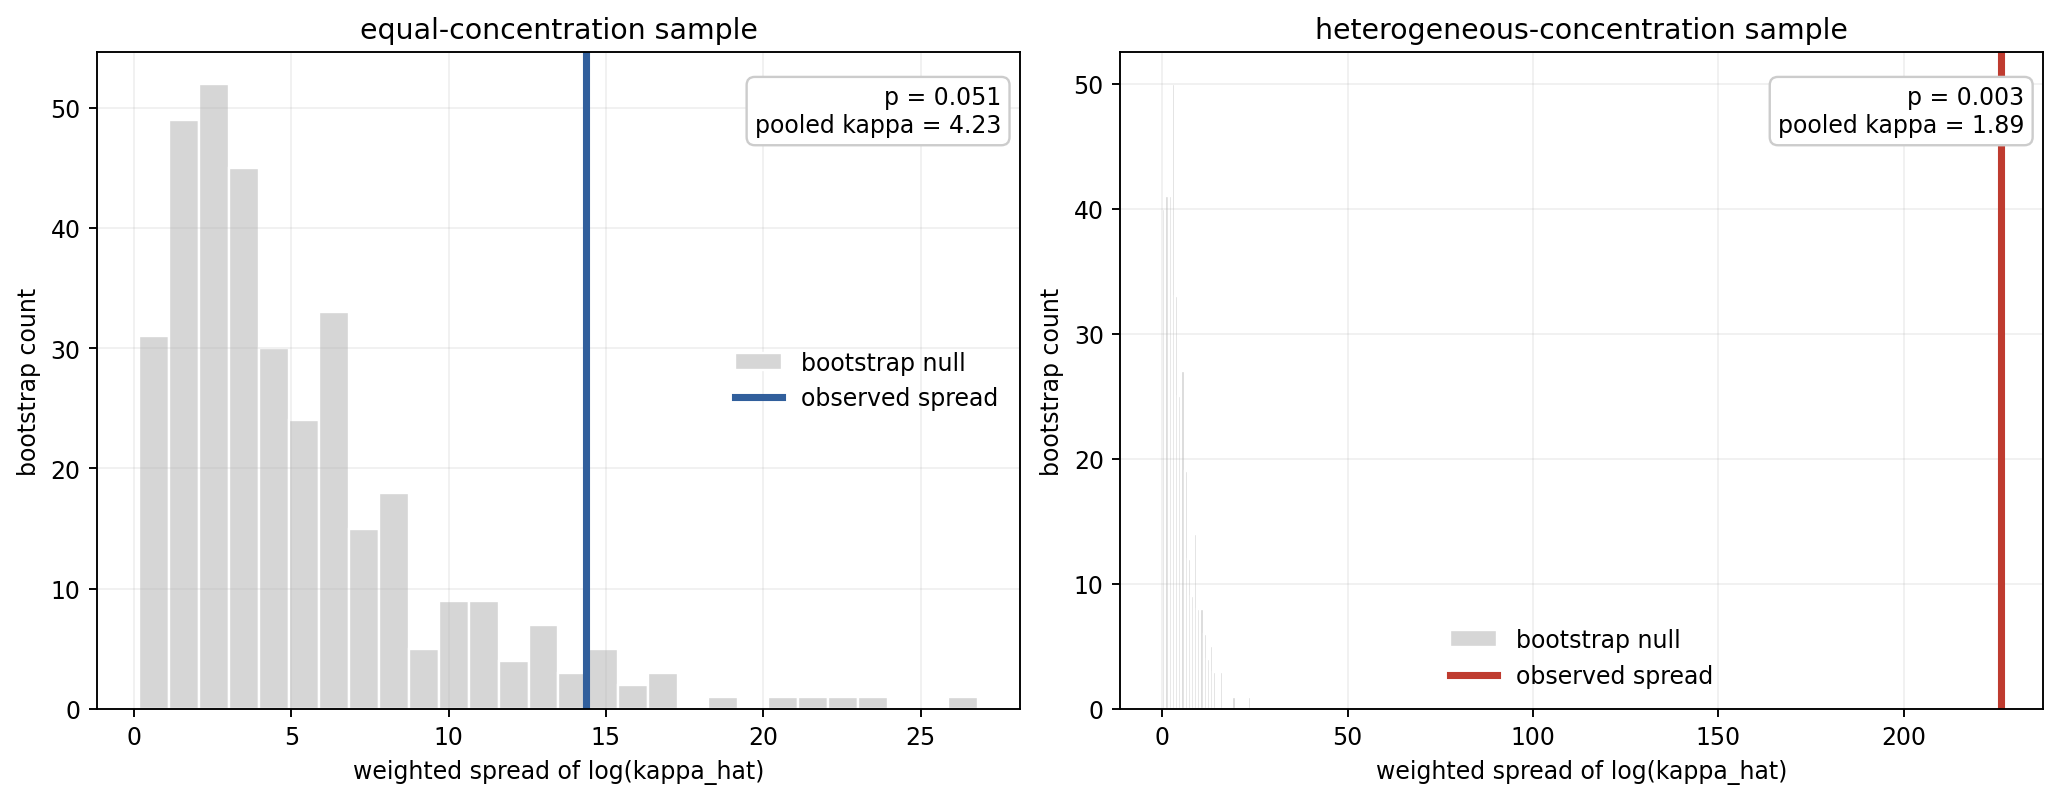

,scenario,observed_spread,bootstrap_p,kappa_hats
0,equal concentration,14.358822,0.051282,"[5.99, 3.27, 5.38, 3.5]"
1,heterogeneous concentration,226.199591,0.002849,"[0.8, 1.12, 6.33, 8.81]"


In [7]:
hom_means = rad(np.array([-20, 5, 28, 48]))
hom_sizes = [54, 52, 56, 50]
equal_conc_groups = [RNG.vonmises(mu, 3.5, n) for mu, n in zip(hom_means, hom_sizes)]
hetero_conc_groups = [RNG.vonmises(mu, k, n) for mu, k, n in zip(hom_means, [0.9, 1.6, 4.5, 9.0], hom_sizes)]

hom_equal = concentration_homogeneity_bootstrap(equal_conc_groups, B=350, seed=710702)
hom_hetero = concentration_homogeneity_bootstrap(hetero_conc_groups, B=350, seed=710703)
assert hom_equal["p_value"] > 0.03, hom_equal["p_value"]
assert hom_hetero["p_value"] < 0.08, hom_hetero["p_value"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ax, result, title, color in [(axes[0], hom_equal, "equal-concentration sample", "#315f9c"), (axes[1], hom_hetero, "heterogeneous-concentration sample", "#bf3b2f")]:
    ax.hist(result["null_stats"], bins=28, color="#d6d6d6", edgecolor="white", label="bootstrap null")
    ax.axvline(result["observed"], color=color, lw=3, label="observed spread")
    ax.set_title(title)
    ax.set_xlabel("weighted spread of log(kappa_hat)")
    ax.set_ylabel("bootstrap count")
    ax.text(0.98, 0.95, f"p = {result['p_value']:.3f}\npooled kappa = {result['pooled_kappa']:.2f}", transform=ax.transAxes, ha="right", va="top", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc"})
    ax.legend(frameon=False)

homogeneity_path = save_matplotlib(fig, TOPIC, "figures", "concentration-homogeneity-bootstrap.png", dpi=170)
plt.close(fig)
display_artifact(homogeneity_path, width=920)

homogeneity_table = pd.DataFrame([
    {"scenario": "equal concentration", "observed_spread": hom_equal["observed"], "bootstrap_p": hom_equal["p_value"], "kappa_hats": np.round(hom_equal["kappa_hats"], 2).tolist()},
    {"scenario": "heterogeneous concentration", "observed_spread": hom_hetero["observed"], "bootstrap_p": hom_hetero["p_value"], "kappa_hats": np.round(hom_hetero["kappa_hats"], 2).tolist()},
])
display(homogeneity_table)

## Von-Misesness Diagnostics

Most tests in this chapter start with a von Mises working model. A practical diagnostic is to ask whether the fitted first harmonic leaves a strong second harmonic behind. After fitting `mu` and `kappa`, a clean von Mises sample should have second-harmonic averages close to the Bessel-function values predicted by the fit. A two-lobed or otherwise asymmetric sample will often fail that check.

The next figure compares a direct von Mises sample with an axial two-lobed sample. Both are circular data, but only the first is well described by one von Mises bump.

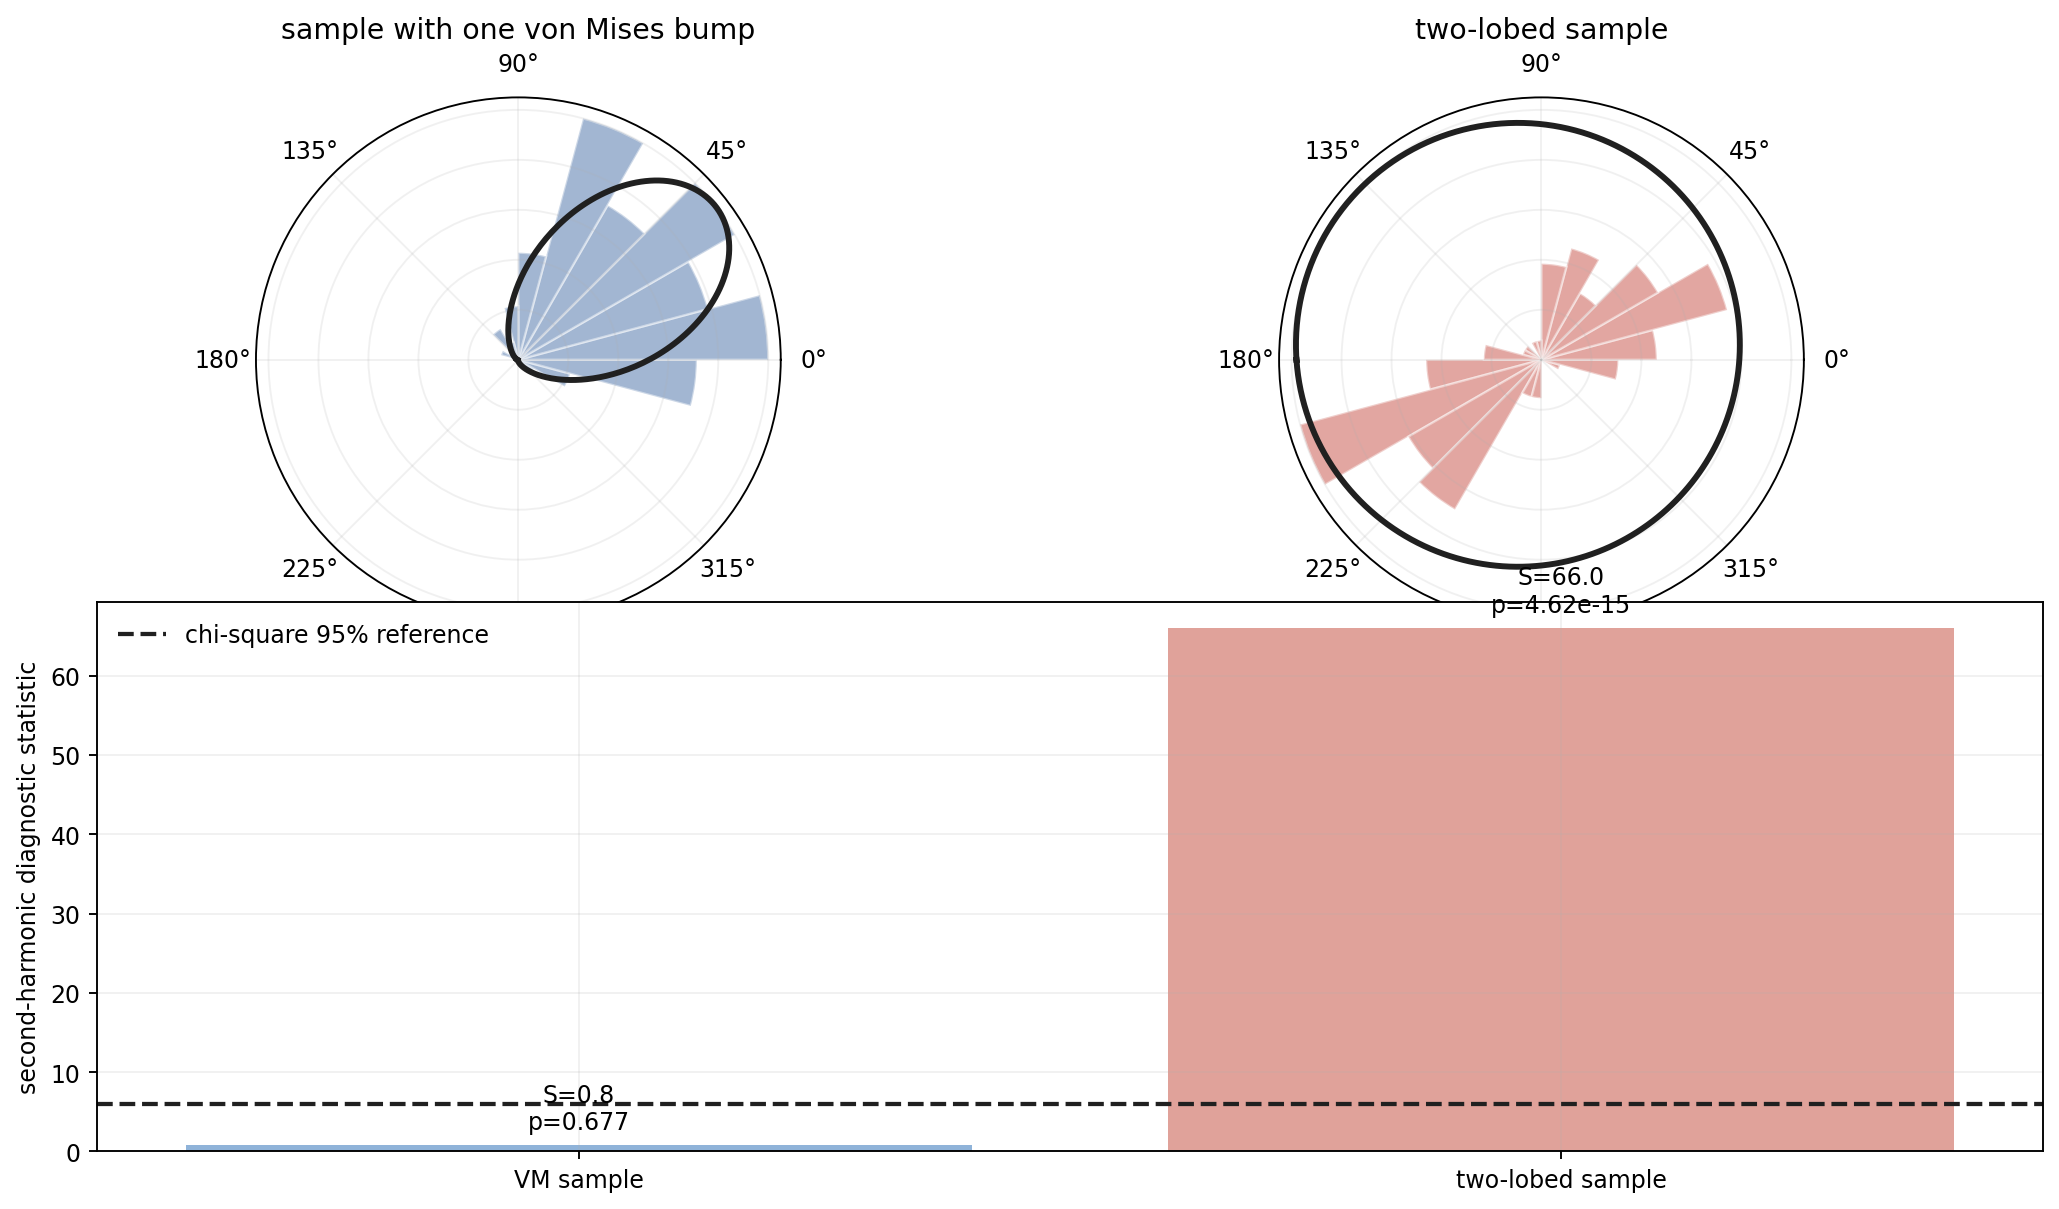

,sample,n,mean_deg,rbar,kappa_hat,cos2_observed,cos2_von_mises_fit,sin2_observed,statistic,p_chi2_df2
0,von Mises,90,37.829453,0.816073,3.084932,0.453047,0.470930,-0.059646,0.781261,6.766301e-01
1,two-lobed,90,147.587925,0.063184,0.126622,-0.383799,0.001999,0.466819,66.017061,4.619312e-15


In [8]:
vm_sample = RNG.vonmises(rad(35), 2.7, 90)
axial_sample = np.concatenate([RNG.vonmises(rad(35), 5.0, 45), RNG.vonmises(rad(215), 5.0, 45)])
vm_diag = second_harmonic_diagnostic(vm_sample)
axial_diag = second_harmonic_diagnostic(axial_sample)
assert axial_diag["statistic"] > vm_diag["statistic"]
assert axial_diag["p_chi2_df2"] < 0.01

def polar_hist_with_fit(ax, theta, diag, title, color):
    bins = np.linspace(-np.pi, np.pi, 25)
    counts, edges = np.histogram(wrap_angle(theta), bins=bins)
    widths = np.diff(edges)
    ax.bar(edges[:-1], counts / counts.max(), width=widths, align="edge", color=color, alpha=0.45, edgecolor="white")
    grid = np.linspace(-np.pi, np.pi, 400)
    fit = von_mises_pdf(grid, rad(diag["mean_deg"]), diag["kappa_hat"])
    ax.plot(grid, fit / fit.max(), color="#202020", lw=2.5)
    ax.set_title(title)
    ax.set_yticklabels([])

fig = plt.figure(figsize=(12, 7), constrained_layout=True)
ax1 = fig.add_subplot(2, 2, 1, projection="polar")
polar_hist_with_fit(ax1, vm_sample, vm_diag, "sample with one von Mises bump", "#315f9c")
ax2 = fig.add_subplot(2, 2, 2, projection="polar")
polar_hist_with_fit(ax2, axial_sample, axial_diag, "two-lobed sample", "#bf3b2f")
ax3 = fig.add_subplot(2, 1, 2)
labels = ["VM sample", "two-lobed sample"]
stat_values = [vm_diag["statistic"], axial_diag["statistic"]]
p_values = [vm_diag["p_chi2_df2"], axial_diag["p_chi2_df2"]]
ax3.bar(labels, stat_values, color=["#8fb3d9", "#e0a29a"])
ax3.axhline(stats.chi2.ppf(0.95, 2), color="#202020", linestyle="--", lw=1.8, label="chi-square 95% reference")
for i, (stat_value, p_value) in enumerate(zip(stat_values, p_values)):
    ax3.text(i, stat_value + max(stat_values) * 0.03, f"S={stat_value:.1f}\np={p_value:.3g}", ha="center")
ax3.set_ylabel("second-harmonic diagnostic statistic")
ax3.legend(frameon=False)

vm_diagnostic_path = save_matplotlib(fig, TOPIC, "figures", "von-misesness-second-harmonic-diagnostic.png", dpi=170)
plt.close(fig)
display_artifact(vm_diagnostic_path, width=920)

diagnostic_table = pd.DataFrame([{"sample": "von Mises", **vm_diag}, {"sample": "two-lobed", **axial_diag}])
display(diagnostic_table[["sample", "n", "mean_deg", "rbar", "kappa_hat", "cos2_observed", "cos2_von_mises_fit", "sin2_observed", "statistic", "p_chi2_df2"]])

## Applied Lab: Stress-Test a Watson-Williams Decision

This lab turns the chapter workflow into a decision table. Each design has three groups. We fit the Watson-Williams mean-direction test and then run the concentration-homogeneity bootstrap. The point is not to automate judgment; it is to make the dependency visible: a small mean-direction p-value is more interpretable when the concentration check does not object.

In [9]:
def lab_design(label, means_deg, kappas, sizes, seed):
    rng = np.random.default_rng(seed)
    groups = [rng.vonmises(rad(mu), kappa, n) for mu, kappa, n in zip(means_deg, kappas, sizes)]
    ww = resultant_decomposition(groups)
    hom = concentration_homogeneity_bootstrap(groups, B=220, seed=seed + 1000)
    if ww["p_WW"] < 0.05 and hom["p_value"] >= 0.05:
        note = "mean-direction signal with compatible concentrations"
    elif ww["p_WW"] < 0.05 and hom["p_value"] < 0.05:
        note = "mean-direction signal, but equal-concentration assumption is suspect"
    elif ww["p_WW"] >= 0.05 and hom["p_value"] < 0.05:
        note = "no mean-direction signal; concentration differs"
    else:
        note = "no mean-direction signal and no concentration warning"
    return {"design": label, "means_deg_used_to_simulate": means_deg, "kappas_used_to_simulate": kappas, "N": ww["N"], "F_WW": ww["F_WW"], "WW_p": ww["p_WW"], "between_loss": ww["between"], "within_loss": ww["within"], "homogeneity_p": hom["p_value"], "fitted_kappas": np.round(hom["kappa_hats"], 2).tolist(), "decision_note": note}

lab_rows = [
    lab_design("same means, equal concentration", [10, 10, 10], [3.2, 3.2, 3.2], [42, 42, 42], 7110),
    lab_design("different means, equal concentration", [-10, 18, 46], [3.2, 3.2, 3.2], [42, 42, 42], 7111),
    lab_design("different means, unequal concentration", [-10, 18, 46], [0.9, 3.2, 8.0], [42, 42, 42], 7112),
]
lab_table = pd.DataFrame(lab_rows)
lab_csv_path = artifact_path(TOPIC, "tables", "applied-lab-watson-williams-decisions.csv")
lab_table.to_csv(lab_csv_path, index=False)
display(lab_table[["design", "F_WW", "WW_p", "homogeneity_p", "fitted_kappas", "decision_note"]])
display_artifact(lab_csv_path)

,design,F_WW,WW_p,homogeneity_p,fitted_kappas,decision_note
0,"same means, equal concentration",0.641763,5.281169e-01,0.131222,"[4.27, 2.97, 2.53]",no mean-direction signal and no concentration ...
1,"different means, equal concentration",19.623266,4.012138e-08,0.303167,"[2.83, 4.24, 3.08]",mean-direction signal with compatible concentr...
2,"different means, unequal concentration",13.335652,5.729858e-06,0.004525,"[1.39, 2.93, 14.17]","mean-direction signal, but equal-concentration..."


## Sanity Checks

The final cell records the checks that make the notebook auditable: artifact existence and size, the exact/numeric resultant identity, the Watson-Williams loss decomposition, simulated confidence-arc coverage, concentration-homogeneity separation, and the von-Misesness diagnostic ordering.

In [10]:
validation_payload = {
    "source_span": {"printed": "119-144", "pdf": "136-160"},
    "mean_direction": {"conditional_p_value": conditional_p, "lr_style_p_value": lr_p, "score_style_p_value": z_p, "estimated_half_width_degrees": float(np.rad2deg(arc_est["half_width"])), "known_kappa_half_width_degrees": float(np.rad2deg(arc_known["half_width"]))},
    "coverage_simulation": coverage_summary,
    "two_sample": {"cosine_rule_residual": float(numeric_cosine_residual), "between_gap": two_dec["between"], "F_WW": two_dec["F_WW"], "p_WW": two_dec["p_WW"]},
    "multi_sample": {"identity_residual": multi_dec["identity_residual"], "between": multi_dec["between"], "within": multi_dec["within"], "F_WW": multi_dec["F_WW"], "p_WW": multi_dec["p_WW"], "correction_factor": multi_dec["correction_factor"]},
    "concentration_homogeneity": {"equal_concentration_p": hom_equal["p_value"], "heterogeneous_concentration_p": hom_hetero["p_value"], "equal_kappa_hats": hom_equal["kappa_hats"], "heterogeneous_kappa_hats": hom_hetero["kappa_hats"]},
    "von_misesness": {"von_mises_statistic": vm_diag["statistic"], "von_mises_p": vm_diag["p_chi2_df2"], "two_lobed_statistic": axial_diag["statistic"], "two_lobed_p": axial_diag["p_chi2_df2"]},
    "applied_lab_rows": len(lab_table),
}
final_sanity = validation_payload
checks_path = save_json(final_sanity, TOPIC, "checks", "chapter-07-validation.json")
artifacts_to_check = [mean_arc_path, two_sample_path, ww_decomp_path, ww_explorer_path, homogeneity_path, vm_diagnostic_path, lab_csv_path, checks_path]
artifact_records = assert_artifacts(artifacts_to_check, min_bytes=100)

assert 0.92 <= coverage_summary["coverage_rate"] <= 0.98
assert abs(numeric_cosine_residual) < 1e-10
assert abs(multi_dec["identity_residual"]) < 1e-10
assert hom_hetero["observed"] > hom_equal["observed"]
assert hom_hetero["p_value"] < hom_equal["p_value"]
assert axial_diag["statistic"] > vm_diag["statistic"]
assert lab_table["design"].nunique() == 3

sanity_payload = {
    "artifact_records": artifact_records,
    "validation_payload_path": str(checks_path.relative_to(BOOK_ROOT)).replace("\\", "/"),
    "core_assertions": {
        "coverage_rate_in_expected_band": True,
        "two_sample_cosine_rule_residual_small": True,
        "multi_sample_decomposition_identity_small": True,
        "heterogeneous_concentration_more_extreme_than_equal_case": True,
        "second_harmonic_flags_two_lobed_case": True,
        "applied_lab_has_three_designs": True,
    },
}
sanity_path = save_json(sanity_payload, TOPIC, "checks", "chapter-07-direct-sanity.json")
all_records = assert_artifacts([*artifacts_to_check, sanity_path], min_bytes=100)
display(pd.DataFrame(all_records))

,path,exists,bytes
0,artifacts/chapter-07/figures/mean-direction-co...,True,187150
1,artifacts/chapter-07/figures/two-sample-result...,True,125732
2,artifacts/chapter-07/figures/watson-williams-d...,True,176108
3,artifacts/chapter-07/interactive/watson-willia...,True,16637
4,artifacts/chapter-07/figures/concentration-hom...,True,70100
5,artifacts/chapter-07/figures/von-misesness-sec...,True,210600
6,artifacts/chapter-07/tables/applied-lab-watson...,True,899
7,artifacts/chapter-07/checks/chapter-07-validat...,True,1671
8,artifacts/chapter-07/checks/chapter-07-direct-...,True,1624


## Takeaways

- A von Mises mean-direction test is naturally an arc test. The confidence set is an angular arc centered at the sample mean direction, and its width depends on both resultant length and concentration.
- The two-sample and multi-sample tests are resultant geometry. The statistic grows when separate group resultants lose length after being forced into one combined resultant.
- Watson-Williams ANOVA is most interpretable after checking concentration homogeneity. Mean-direction disagreement and concentration disagreement are different geometric failures.
- A fitted von Mises model captures a first harmonic. Second-harmonic leftovers are a direct diagnostic for shapes that need more than one von Mises bump.
- The notebook's checks tie the visuals to identities: cosine-rule geometry, ANOVA loss decomposition, simulation coverage, artifact integrity, and diagnostic separation.